# Powder and Heat Treatment

Two small forms describe what goes into a build and what happens to it afterwards. Neither has many entries, but both sit upstream of every mechanical property in the archive.

- **Raw Powder Details** — feedstock chemistry, particle sizing and provenance for 11 powder lots
- **Sample Heat Treatment Record** — stress relief and subsequent heat-treatment steps for 9 records

Both nest their real content in lists: `composition` for powder, `heat_treatment` for the treatment schedule.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "imqcam.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from imqcam import entries_to_frame, explode_records, fetch_entries, get_client

BLUE, ORANGE, GREEN = "#4C8BE2", "#E26C4C", "#4CE2A7"
RAW_POWDER = "663e6d21b18fa1c426e939ab"
HEAT_TREATMENT = "69fa18be514cf501621588cc"

client = get_client()
powders = fetch_entries(client, form_id=RAW_POWDER, page_size=100)
treatments = fetch_entries(client, form_id=HEAT_TREATMENT, page_size=100)

print(f"{len(powders)} powder lots, {len(treatments)} heat treatment records")

11 powder lots, 9 heat treatment records


## Powder lots

One row per lot. `rawPowderID` is the key that Printer Build entries point back at through their own `rawPowderID` field.

In [2]:
powder_frame = entries_to_frame(powders)
powder_frame[["rawPowderID", "alloy", "supplyCompany", "purchaser", "sampleNumber"]]

,rawPowderID,alloy,supplyCompany,purchaser,sampleNumber
0,PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64...,Ti-6Al-4V,ATI,CMU,1
1,PWD_Ti-6Al-4V_ATI_CMU_001,Ti-6Al-4V,ATI,CMU,1
2,PWD_Ti-6Al-4V_TEK_CMU_001,Ti-6Al-4V,TEK,CMU,1
3,PWD_alloy718_EOS_CMU_001,alloy718,EOS,CMU,1
4,PWD_alloy718_EOS_CMU_002,alloy718,EOS,CMU,2
5,PWD_alloy718_EOS_CMU_003,alloy718,EOS,CMU,3
6,PWD_Ti-6Al-4V_ATI_CMU_002,Ti-6Al-4V,ATI,CMU,2
7,PWD_alloy718_UNK_APL_000,alloy718,UNK,APL,0
8,PWD_alloy718_UNK_CMU_000,alloy718,UNK,CMU,0
9,PWD_Ti-6Al-4V_APC_APL_000,Ti-6Al-4V,APC,APL,0


### Data overview

- **`rawPowderID`** — lot identifier, referenced by Printer Build
- **`alloy`** — nominal alloy designation
- **`supplyCompany`, `purchaser`** — provenance
- **`characteristics.*`** — particle size distribution and virgin/recycled fraction
- **`composition`** — a list of measured element amounts

The particle-size fields are the sparse part, so check coverage before relying on them:

In [3]:
characteristics = [c for c in powder_frame.columns if c.startswith("characteristics.")]
coverage = pd.DataFrame(
    {
        "field": characteristics,
        "present": [powder_frame[c].notna().sum() for c in characteristics],
        "of": len(powder_frame),
    }
)
coverage["fill"] = (coverage["present"] / coverage["of"]).map("{:.0%}".format)
coverage

,field,present,of,fill
0,characteristics.maxSize,8,11,73%
1,characteristics.minSize,8,11,73%
2,characteristics.tested,10,11,91%
3,characteristics.virginPercent,8,11,73%
4,characteristics.fiftiethPercentileSize,6,11,55%
5,characteristics.ninetiethPercentileSize,6,11,55%
6,characteristics.tenthPercentileSize,6,11,55%


## Powder chemistry

`composition` holds one record per alloying element. Exploding it gives a tidy element-by-lot table.

The balance element is recorded with `amount = 0` and `isBalance = True` — it is not measured, it is whatever remains. Treating that zero as a measurement would put titanium at 0% in a titanium alloy, so it needs explicit handling.

In [4]:
composition = explode_records(powders, "composition")

print(f"{len(composition)} element records across {composition['uniqueId'].nunique()} lots")
print(f"\nBalance entries: {composition['isBalance'].sum()}")
print(composition[composition["isBalance"]][["uniqueId", "element", "amount", "method"]]
      .head()
      .to_string(index=False))

132 element records across 11 lots

Balance entries: 8
                                            uniqueId element  amount                                    method
PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64STD004      Ti     0.0                          NA (for balance)
                           PWD_Ti-6Al-4V_ATI_CMU_001      Ti     0.0 WET (Inductively coupled plasma emission)
                           PWD_Ti-6Al-4V_TEK_CMU_001      Ti     0.1                          NA (for balance)
                            PWD_alloy718_EOS_CMU_001      Fe     0.0 WET (Inductively coupled plasma emission)
                            PWD_alloy718_EOS_CMU_002      Fe     0.0                          NA (for balance)


**The lots are not all the same alloy.** Seven are Ti-6Al-4V and four are alloy718, a nickel-chromium superalloy. Pooling them produces a meaningless average — nickel at 44% in a table that also contains titanium alloys. Composition has to be grouped by alloy.

In [5]:
alloy_by_lot = dict(zip(powder_frame["uniqueId"], powder_frame["alloy"]))

measured = composition[~composition["isBalance"].fillna(False)].copy()
measured["amount"] = pd.to_numeric(measured["amount"], errors="coerce")
measured["alloy"] = measured["uniqueId"].map(alloy_by_lot)

print(powder_frame["alloy"].value_counts().to_string())

by_element = (
    measured.groupby(["alloy", "element"])["amount"]
    .agg(["count", "mean", "std"])
    .round(4)
    .sort_values(["alloy", "mean"], ascending=[True, False])
)
by_element

alloy
alloy718     6
Ti-6Al-4V    5


count     mean     std
alloy     element                        
Ti-6Al-4V Al           5   6.2920  0.1566
          V            5   3.9500  0.0552
          Fe           5   0.1960  0.0270
          O            5   0.1458  0.0532
          Ni           1   0.0140     NaN
          N            4   0.0125  0.0017
          Cr           1   0.0100     NaN
          Cu           1   0.0100     NaN
          Mn           1   0.0100     NaN
          Mo           1   0.0100     NaN
          Si           1   0.0100     NaN
          C            4   0.0099  0.0081
          H            4   0.0019  0.0012
          Y            4   0.0008  0.0002
alloy718  Ni           5  53.2700  0.2915
          Cr           5  18.9260  0.5553
          Fe           2  18.0600  0.0000
          Nb           5   5.1320  0.0672
          Mo           5   3.1800  0.0644
          Ti           6   0.8650  0.4243
          Al           5   0.5240  0.0241
          Si           5   0.0376  0.0217
          C            5   0.0360  0.0055
          Co           5   0.0220  0.0179
          O            4   0.0210  0.0038
          Mn           5   0.0176  0.0033
          N            4   0.0127  0.0024
          Cu           5   0.0116  0.0080
          Ta           2   0.0100  0.0000
          P            4   0.0075  0.0029
          S            4   0.0035  0.0010
          B            4   0.0015  0.0010
          H            2   0.0006  0.0001

Split by alloy the numbers land where they should: aluminium near 6% and vanadium near 4% in the Ti-6Al-4V lots, nickel and chromium dominating the alloy718 lots, with interstitials and trace elements orders of magnitude below. A log scale is the only way to show both on one axis.

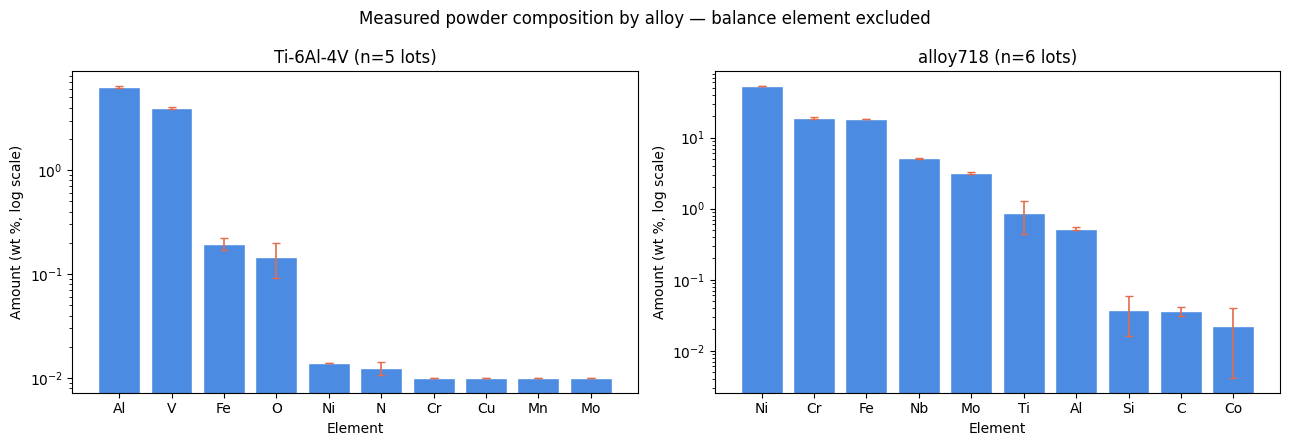

In [6]:
alloys = [a for a in measured["alloy"].dropna().unique()]
fig, axes = plt.subplots(1, len(alloys), figsize=(6.5 * len(alloys), 4.5), squeeze=False)

for ax, alloy in zip(axes[0], alloys):
    subset = measured[measured["alloy"] == alloy]
    stats = (
        subset.groupby("element")["amount"].agg(["mean", "std"])
        .query("mean > 0").sort_values("mean", ascending=False).head(10)
    )
    ax.bar(stats.index, stats["mean"], yerr=stats["std"].fillna(0), color=BLUE,
           edgecolor="white", error_kw=dict(ecolor=ORANGE, lw=1.2, capsize=3))
    ax.set_yscale("log")
    ax.set_xlabel("Element")
    ax.set_ylabel("Amount (wt %, log scale)")
    ax.set_title(f"{alloy} (n={subset['uniqueId'].nunique()} lots)")

fig.suptitle("Measured powder composition by alloy — balance element excluded")
plt.tight_layout()
plt.show()

## Particle size distribution

Where the percentiles were recorded, they describe the powder cut — a standard 15–53 µm range for laser powder-bed fusion.

In [7]:
size_columns = ["characteristics.tenthPercentileSize", "characteristics.fiftiethPercentileSize",
                "characteristics.ninetiethPercentileSize", "characteristics.minSize",
                "characteristics.maxSize"]
available = [c for c in size_columns if c in powder_frame.columns]
sizes = powder_frame[["rawPowderID"] + available].dropna(subset=available, how="all")

sizes.rename(columns=lambda c: c.replace("characteristics.", ""))

,rawPowderID,tenthPercentileSize,fiftiethPercentileSize,ninetiethPercentileSize,minSize,maxSize
0,PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64...,NaN,NaN,NaN,15.0,53.0
1,PWD_Ti-6Al-4V_ATI_CMU_001,NaN,NaN,NaN,21.0,47.0
2,PWD_Ti-6Al-4V_TEK_CMU_001,27.00,39.0,60.00,20.0,53.0
3,PWD_alloy718_EOS_CMU_001,16.00,33.0,57.00,14.0,75.0
6,PWD_Ti-6Al-4V_ATI_CMU_002,27.34,42.5,60.89,15.0,63.0
8,PWD_alloy718_UNK_CMU_000,20.00,33.0,45.00,11.0,53.0
9,PWD_Ti-6Al-4V_APC_APL_000,22.00,33.0,45.00,15.0,45.0
10,PWD_alloy718_6K_CMU_000,20.00,33.0,45.00,11.0,53.0


## Heat treatment

Every record carries a `stress_relief` block. The `heat_treatment` list holds any further steps — solution treatment, ageing — and is empty on some records.

In [8]:
treatment_frame = entries_to_frame(treatments)
stress_relief_columns = [c for c in treatment_frame.columns if c.startswith("stress_relief.")]

treatment_frame[["heat_treatment_id", "igsn"] + stress_relief_columns].rename(
    columns=lambda c: c.replace("stress_relief.", "SR ")
)

,heat_treatment_id,igsn,SR cooling_method,SR environment,SR files.file,SR files.targetPath,SR ramp_up_C_per_min,SR temperature_C,SR time_hr
0,HT_850SR_z6nagm,APLMAL00001,Furnace,Ar,,HT_850SR_z6nagm,2.5,850,2.0
1,HT_1066SR_1163+HIP-1066-760-649_g7fagw,CMXMAG00001-002,Furnace,Ar,6a6e142a0c9bc47abeb6a27c,HT_1066SR_1163+HIP-1066-760-649_g7fagw,20.0,1066,1.5
2,HT_1066SR_1130-760-649_14fv6xc,CMXMAG00001-004,Furnace,Ar,6a6e148b05568ca3b190b1fe,HT_1066SR_1130-760-649_14fv6xc,20.0,1066,1.5
3,HT_593SR_ej7nt4,CMXMAL00007-031,Furnace,Ar,,HT_593SR_ej7nt4,5.0,593,2.0
4,HT_593SR_820+HIP_g9i8zc,CMXMAL00007-032,Furnace,Ar,,HT_593SR_820+HIP_g9i8zc,5.0,593,2.0
5,HT_593SR_950+HIP_8k2saw,CMXMAL00007-033,Furnace,Ar,,HT_593SR_950+HIP_8k2saw,5.0,593,2.0
6,HT_593SR_820_mrzjq2,CMXMAL00007-034,Furnace,Ar,,HT_593SR_820_mrzjq2,5.0,593,2.0
7,HT_593SR_950_1kwq4ve,CMXMAL00007-035,Furnace,Ar,,HT_593SR_950_1kwq4ve,5.0,593,2.0
8,HT_593SR_820_ugsmuq,CMXMAL00025-001,Furnace,Ar,,HT_593SR_820_ugsmuq,5.0,593,2.0


### Data overview

- **`heat_treatment_id`** — treatment identifier
- **`igsn`** — the sample treated, parsed from the `lookup` list
- **`stress_relief.temperature_C`, `.time_hr`, `.ramp_up_C_per_min`** — the stress-relief schedule
- **`stress_relief.environment`, `.cooling_method`** — atmosphere and cooling route

Subsequent steps live in the `heat_treatment` list:

In [9]:
steps = explode_records(treatments, "heat_treatment")

print(f"{len(steps)} additional steps across {steps['uniqueId'].nunique()} records")
print(f"Records with no further steps: "
      f"{len(treatments) - steps['uniqueId'].nunique()} of {len(treatments)}")

steps[[c for c in steps.columns if c not in ("_id", "formId", "recordIndex")]]

12 additional steps across 7 records
Records with no further steps: 2 of 9


,uniqueId,igsn,cooling_method,environment,ramp_up_C_per_min,temperature_C,time_hr,HIP.pressure_MPa,files.file,files.targetPath,HIP
0,HT_1066SR_1163+HIP-1066-760-649_g7fagw,CMXMAG00001-002,Furnace,Ar,5.00,1163,4,103.0,6a6e138805568ca3b190b1f7,HT_1066SR_1163+HIP-1066-760-649_g7fagw,NaN
1,HT_1066SR_1163+HIP-1066-760-649_g7fagw,CMXMAG00001-002,Argon,Vacuum,4.00,1066,1,NaN,"6a6e13bb134bc2680466f093,6a6e13c905568ca3b190b1fa",HT_1066SR_1163+HIP-1066-760-649_g7fagw,NaN
2,HT_1066SR_1163+HIP-1066-760-649_g7fagw,CMXMAG00001-002,Furnace,Vacuum,14.00,760,10,NaN,"6a6e14010c9bc47abeb6a279,6a6e141160446030364e6420",HT_1066SR_1163+HIP-1066-760-649_g7fagw,NaN
3,HT_1066SR_1163+HIP-1066-760-649_g7fagw,CMXMAG00001-002,Argon,Vacuum,0.00,649,10,NaN,,HT_1066SR_1163+HIP-1066-760-649_g7fagw,NaN
4,HT_1066SR_1130-760-649_14fv6xc,CMXMAG00001-004,Argon,Vacuum,3.50,1130,1,NaN,"6a6e14a7134bc2680466f099,6a6e14ac134bc2680466f09c",HT_1066SR_1130-760-649_14fv6xc,NaN
5,HT_1066SR_1130-760-649_14fv6xc,CMXMAG00001-004,Furnace,Vacuum,7.25,760,10,NaN,"6a6e14cb60446030364e6426,6a6e14d260446030364e6429",HT_1066SR_1130-760-649_14fv6xc,NaN
6,HT_1066SR_1130-760-649_14fv6xc,CMXMAG00001-004,Argon,Vacuum,0.00,649,10,NaN,,HT_1066SR_1130-760-649_14fv6xc,NaN
7,HT_593SR_820+HIP_g9i8zc,CMXMAL00007-032,Furnace,Vacuum,5.00,820,2,190.0,,HT_593SR_820+HIP_g9i8zc,NaN
8,HT_593SR_950+HIP_8k2saw,CMXMAL00007-033,Furnace,Vacuum,5.00,950,2,190.0,,HT_593SR_950+HIP_8k2saw,NaN
9,HT_593SR_820_mrzjq2,CMXMAL00007-034,Furnace,Vacuum,5.00,820,2,NaN,,HT_593SR_820_mrzjq2,NaN


## Stress relief schedules

The schedules cluster into a small number of distinct recipes rather than varying continuously.

In [10]:
schedule = treatment_frame.copy()
for column in ("stress_relief.temperature_C", "stress_relief.time_hr",
               "stress_relief.ramp_up_C_per_min"):
    schedule[column] = pd.to_numeric(schedule[column], errors="coerce")

recipes = (
    schedule.groupby(["stress_relief.temperature_C", "stress_relief.time_hr",
                      "stress_relief.environment", "stress_relief.cooling_method"])
    .size()
    .rename("records")
    .reset_index()
    .sort_values("records", ascending=False)
)
recipes

,stress_relief.temperature_C,stress_relief.time_hr,stress_relief.environment,stress_relief.cooling_method,records
0,593,2.0,Ar,Furnace,6
2,1066,1.5,Ar,Furnace,2
1,850,2.0,Ar,Furnace,1


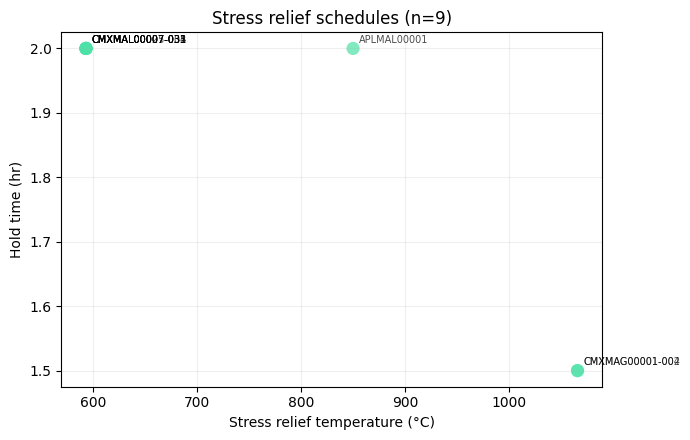

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(schedule["stress_relief.temperature_C"], schedule["stress_relief.time_hr"],
           s=90, alpha=0.7, color=GREEN, edgecolors="none")
for _, row in schedule.iterrows():
    ax.annotate(row["igsn"] or "",
                (row["stress_relief.temperature_C"], row["stress_relief.time_hr"]),
                fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Stress relief temperature (°C)")
ax.set_ylabel("Hold time (hr)")
ax.set_title(f"Stress relief schedules (n={len(schedule)})")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Linking powder to builds

Printer Build entries reference powder lots by Girder entry id in their `rawPowderID` field, so the two forms join directly. This is the one place in the archive where feedstock chemistry can be traced to a specific build.

In [12]:
PRINTER_BUILD = "66425a71b18fa1c426e93aa0"
builds = fetch_entries(client, form_id=PRINTER_BUILD, page_size=100)
powder_by_id = {e["_id"]: e.get("data", {}).get("rawPowderID") for e in powders}

links = []
for build in builds:
    referenced = build.get("data", {}).get("rawPowderID") or []
    for powder_id in referenced:
        links.append(
            {
                "build": build.get("uniqueId"),
                "igsn": build.get("data", {}).get("assignedIGSN"),
                "powderEntryId": powder_id,
                "rawPowderID": powder_by_id.get(powder_id, "(not found)"),
            }
        )

link_frame = pd.DataFrame(links)
print(f"{len(link_frame)} build-to-powder references across {len(builds)} builds")
link_frame

8 build-to-powder references across 7 builds


,build,igsn,powderEntryId,rawPowderID
0,20241219_CMU_Ti-6Al-4V,CMXMAL00007,663e8182b18fa1c426e93a7b,PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64...
1,20240220_CMU_Ti-6Al-4V,CMXMAL00008,663e8182b18fa1c426e93a7b,PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64...
2,20241202_CMU_Ti-6Al-4V,CMXMAL00010,66575b17cfd02da280fcb958,PWD_Ti-6Al-4V_ATI_CMU_001
3,20251215_CMU_Ti-6Al-4V,CMXMAL00024,691b712f51d2cf4a1aa1d363,PWD_Ti-6Al-4V_ATI_CMU_002
4,20260114_CMU_alloy718,CMXMAG00001,6a57cd3a9fbc9c8550a74d4d,PWD_alloy718_6K_CMU_000
5,20251220_CMU_Ti-6Al-4V,CMXMAL00025,691b712f51d2cf4a1aa1d363,PWD_Ti-6Al-4V_ATI_CMU_002
6,20251220_CMU_Ti-6Al-4V,CMXMAL00025,663e8182b18fa1c426e93a7b,PWD_Ti-6Al-4V_ATI_CMU_001_batch-1609_heat-9E64...
7,20260518_APL_Ti-6Al-4V,APLMAL00001,6a3e91bd59b05db59c7d82a2,PWD_Ti-6Al-4V_APC_APL_000
